# 0. Data Denoising & LFP Comparison
This notebook focuses on:
- **Data Denoising**: Applying Gaussian smoothing to spike trains.
- **LFP Comparison**: Validating spike rate dynamics against Local Field Potentials.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache

# Import custom style module
import sys
sys.path.append(os.path.dirname(os.path.abspath(''))) # Ensure we can import from current dir
import viz_style
viz_style.set_architectural_style()

# Setup
%matplotlib inline

# Load Data
output_dir = "../Dataset/RAW"
manifest_path = os.path.join(output_dir, "manifest.json")
cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)
session_id = 750749662
session = cache.get_session_data(session_id)

# Get Response Matrix
stimulus_name = "natural_movie_one"
movie_table = session.get_stimulus_table(stimulus_name)
frame_duration = movie_table['duration'].mean()
units = session.units
spike_counts = session.presentationwise_spike_counts(
    stimulus_presentation_ids=movie_table.index.values,
    bin_edges=np.array([0, frame_duration]),
    unit_ids=units.index.values
)
response_matrix_all = spike_counts.sum(dim="time_relative_to_stimulus_onset")
df_response = pd.DataFrame(response_matrix_all.values, index=movie_table.index, columns=units.index)
df_response['frame'] = movie_table['frame']
average_response_matrix_total = df_response.groupby('frame').mean()
print("Data Loaded.")

/opt/anaconda3/envs/TDA/lib/python3.11/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Data Loaded.


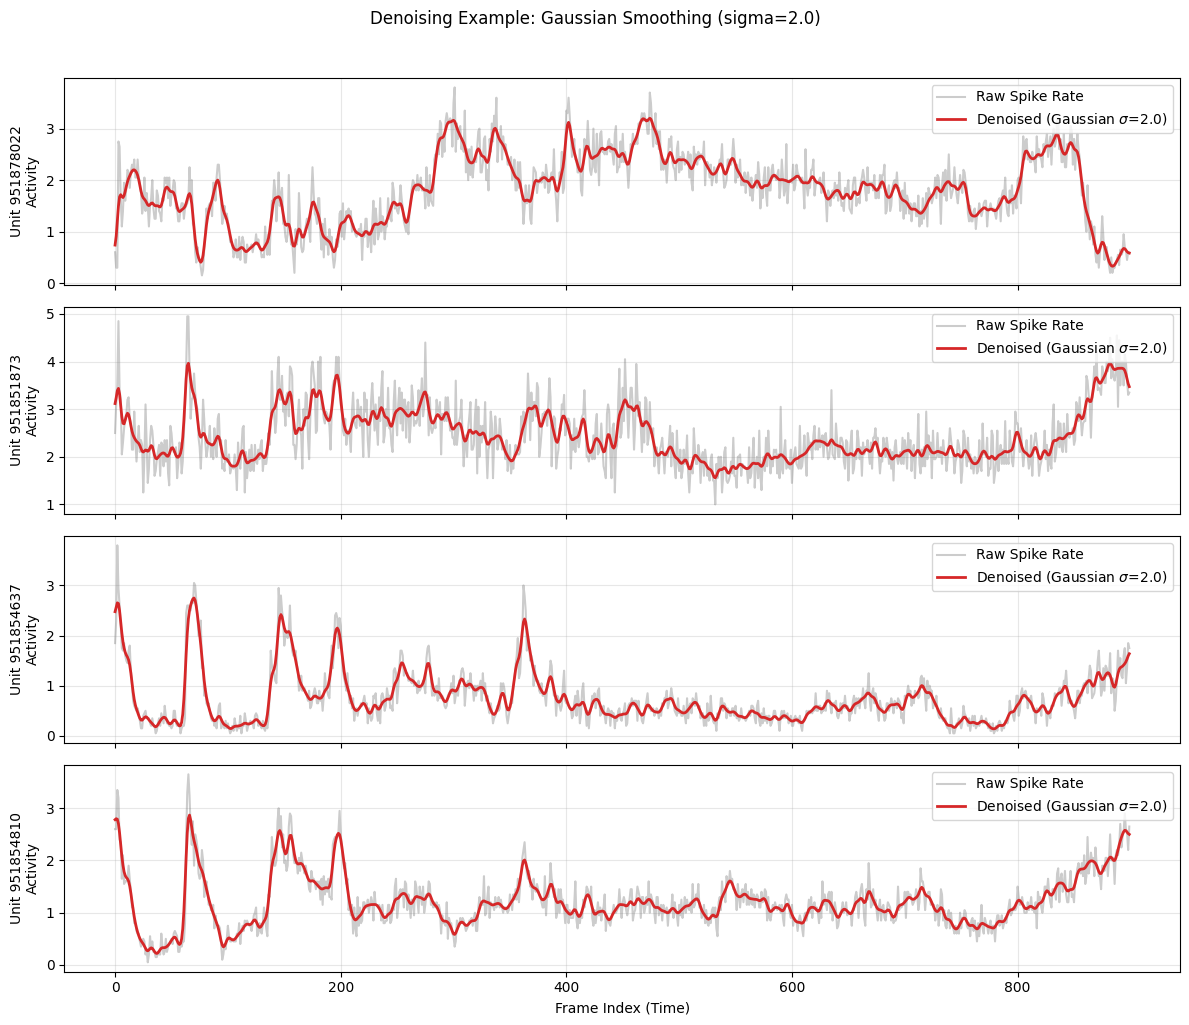

In [ ]:
# %% [markdown]
# ## Data Denoising Example
# Before proceeding with high-dimensional analysis, it is often beneficial to denoise the neural activity.
# Here we demonstrate **Gaussian Smoothing** (temporal smoothing) on a few sample units.
# This helps to smooth out the discrete spike counts into a continuous firing rate estimate.

# %%
# Select a few units with high variance (active neurons) to visualize
variances = average_response_matrix_total.var()
top_units = variances.nlargest(4).index
sigma = 2.0  # Smoothing parameter (standard deviation in frames)

fig, axes = plt.subplots(len(top_units), 1, figsize=(12, 10), sharex=True)

for i, unit_id in enumerate(top_units):
    raw_trace = average_response_matrix_total[unit_id].values
    denoised_trace = gaussian_filter1d(raw_trace, sigma=sigma)
    
    axes[i].plot(raw_trace, label="Raw Spike Rate", alpha=0.4, color='gray')
    axes[i].plot(denoised_trace, label=f"Denoised (Gaussian $\sigma$={sigma})", color='tab:red', linewidth=2)
    axes[i].set_ylabel(f"Unit {unit_id}\nActivity")
    axes[i].legend(loc="upper right")
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Frame Index (Time)")
plt.suptitle(f"Denoising Example: Gaussian Smoothing (sigma={sigma})", y=1.02)
plt.tight_layout()
plt.show()

Selected Probe for LFP: probeC (ID: 769322806)
Loading LFP data (this may take a moment)...


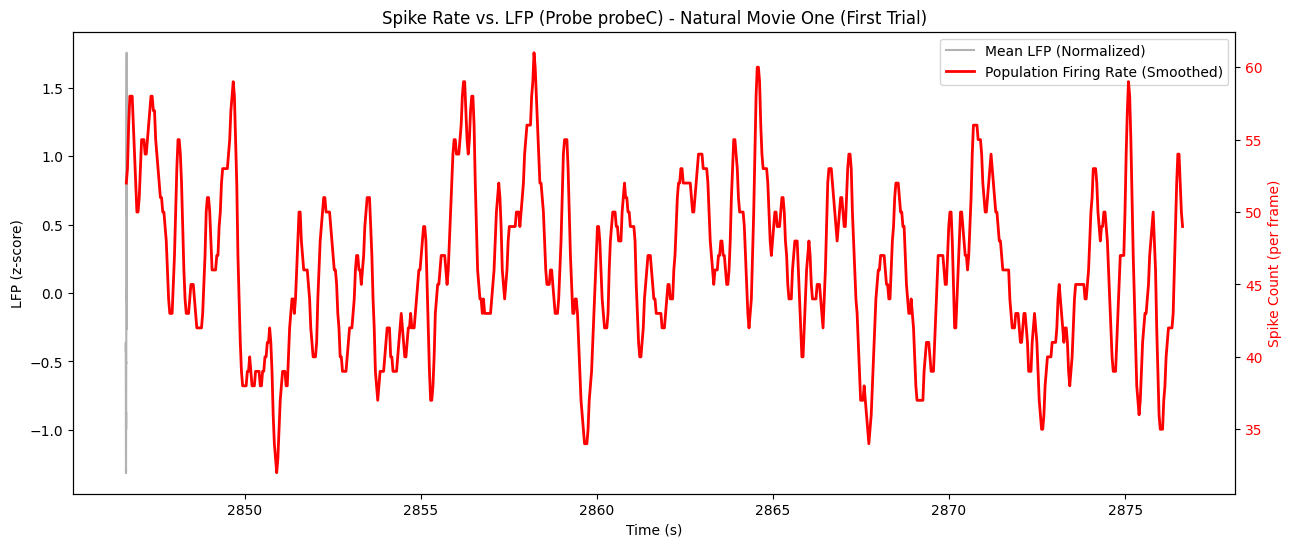

In [ ]:
# %% [markdown]
# ## Spike Rate vs. LFP Comparison
# We compare the population firing rate (Spikes) with the Local Field Potential (LFP).
# LFP reflects the summed synaptic activity in a local area and is often correlated with the aggregate spiking activity.
# 
# 1. Load LFP data for a specific probe (e.g., Probe C which often targets VISp).
# 2. Align LFP time with Movie Frames.
# 3. Plot Population Spike Rate vs. LFP Power/Trace.

# %%
# 1. Select a Probe for LFP (e.g., the one with the most VISp units)
# Find probe with max VISp units
visp_counts = session.units[session.units.ecephys_structure_acronym == 'VISp'].groupby('probe_id').size()
if not visp_counts.empty:
    target_probe_id = visp_counts.idxmax()
    probe_name = session.probes.loc[target_probe_id].description
    print(f"Selected Probe for LFP: {probe_name} (ID: {target_probe_id})")
else:
    # Fallback
    target_probe_id = session.probes.index[0]
    print(f"No VISp units found. Using first probe: {target_probe_id}")

# 2. Load LFP Data
print("Loading LFP data (this may take a moment)...")
lfp = session.get_lfp(target_probe_id)

# 3. Align LFP to Movie Times
# Movie times
stim_table = session.get_stimulus_table("natural_movie_one")
start_time = stim_table.iloc[0]['start_time']
end_time = stim_table.iloc[0]['stop_time'] # Just the first trial for visualization

# Slice LFP for the first movie trial
lfp_slice = lfp.sel(time=slice(start_time, end_time))

# 4. Calculate Population Spike Rate (Sum of all units)
# We use the first trial's spike counts
units_on_probe = session.units[session.units.probe_id == target_probe_id].index.values
spike_counts_trial1 = session.presentationwise_spike_counts(
    stimulus_presentation_ids=stim_table.index.values[:900], # First 900 frames (1st repeat)
    bin_edges=np.array([0, frame_duration]),
    unit_ids=units_on_probe
)
# Sum across units to get population rate
pop_firing_rate = spike_counts_trial1.sum(dim="unit_id").sum(dim="time_relative_to_stimulus_onset").values

# 5. Visualization
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plot LFP (Mean across channels)
# LFP is high frequency, so we might see a lot of noise. 
# We plot the mean LFP across all channels on this probe.
lfp_mean = lfp_slice.mean(dim="channel").values
lfp_time = lfp_slice.time.values
# Normalize LFP for visualization
lfp_norm = (lfp_mean - lfp_mean.mean()) / lfp_mean.std()

ax1.plot(lfp_time, lfp_norm, color='black', alpha=0.3, label="Mean LFP (Normalized)")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("LFP (z-score)", color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Plot Population Firing Rate
# Align firing rate time (approximate center of frame)
frame_times = stim_table.iloc[:900]['start_time'].values + frame_duration/2

ax2 = ax1.twinx()
# Smooth the firing rate for better comparison
pop_rate_smooth = gaussian_filter1d(pop_firing_rate, sigma=2)
ax2.plot(frame_times, pop_rate_smooth, color='red', linewidth=2, label="Population Firing Rate (Smoothed)")
ax2.set_ylabel("Spike Count (per frame)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title(f"Spike Rate vs. LFP (Probe {probe_name}) - Natural Movie One (First Trial)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.show()